In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Set Correct Paths**

In [2]:
from pathlib import Path

DATA_ROOT = Path("/content/drive/MyDrive/content/sr_project")

HR_DIR = DATA_ROOT / "HR_256"
LR_DIR = DATA_ROOT / "LR_x4"

print("HR_DIR:", HR_DIR)
print("LR_DIR:", LR_DIR)

assert HR_DIR.exists(), "HR_256 folder not found!"
assert LR_DIR.exists(), "LR_x4 folder not found!"

HR_DIR: /content/drive/MyDrive/content/sr_project/HR_256
LR_DIR: /content/drive/MyDrive/content/sr_project/LR_x4


# **Define Train/Test IDs**

In [3]:
def make_ids(start, end):
    return [f"{i:04d}" for i in range(start, end+1)]

train_ids = make_ids(0, 99)
test_ids  = make_ids(100, 109)

print("Train:", train_ids[:3], "...", train_ids[-3:])
print("Test:", test_ids)

Train: ['0000', '0001', '0002'] ... ['0097', '0098', '0099']
Test: ['0100', '0101', '0102', '0103', '0104', '0105', '0106', '0107', '0108', '0109']


# **Dataset Class (Patch Training)**

In [33]:
from pathlib import Path
from PIL import Image
import torchvision.transforms.functional as TF
import random, torch
from torch.utils.data import Dataset

def find_img(folder: Path, id_: str):
    for ext in [".png", ".jpg", ".jpeg"]:
        p = folder / f"{id_}{ext}"
        if p.exists():
            return p
    raise FileNotFoundError(f"Missing file for id={id_} in {folder}")

class SRDataset(Dataset):
    # returns LR patch (p×p) and HR patch ((4p)×(4p))
    def __init__(self, lr_dir, hr_dir, ids, scale=4, patch_size=32, augment=True):
        self.lr_dir = Path(lr_dir)
        self.hr_dir = Path(hr_dir)
        self.ids = ids
        self.scale = scale
        self.patch_size = patch_size
        self.augment = augment

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        id_ = self.ids[idx]
        lr = TF.to_tensor(Image.open(find_img(self.lr_dir, id_)).convert("RGB"))
        hr = TF.to_tensor(Image.open(find_img(self.hr_dir, id_)).convert("RGB"))

        _, h, w = lr.shape
        p = self.patch_size
        s = self.scale

        top = random.randint(0, h - p)
        left = random.randint(0, w - p)

        lr_patch = lr[:, top:top+p, left:left+p]
        hr_patch = hr[:, top*s:(top+p)*s, left*s:(left+p)*s]

        if self.augment:
            if random.random() < 0.5:
                lr_patch = TF.hflip(lr_patch); hr_patch = TF.hflip(hr_patch)
            if random.random() < 0.5:
                lr_patch = TF.vflip(lr_patch); hr_patch = TF.vflip(hr_patch)
            k = random.randint(0, 3)
            if k:
                lr_patch = torch.rot90(lr_patch, k, [1,2])
                hr_patch = torch.rot90(hr_patch, k, [1,2])

        return lr_patch, hr_patch

class SRImageDataset(Dataset):
    def __init__(self, lr_dir, hr_dir, ids):
        self.lr_dir = Path(lr_dir)
        self.hr_dir = Path(hr_dir)
        self.ids = ids
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        id_ = self.ids[idx]
        lr = TF.to_tensor(Image.open(find_img(self.lr_dir, id_)).convert("RGB"))
        hr = TF.to_tensor(Image.open(find_img(self.hr_dir, id_)).convert("RGB"))
        return lr, hr, id_

# **Dataloaders**

In [26]:
train_dataset = SRDataset(LR_DIR, HR_DIR, train_ids, patch_size=24)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print("Train batches:", len(train_loader))

Train batches: 4


# **SRCNN Model (×4)**

In [35]:
import torch
import torch.nn as nn

class SRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 9, padding=4),
            nn.ReLU(True),
            nn.Conv2d(64, 32, 5, padding=2),
            nn.ReLU(True),
            nn.Conv2d(32, 3, 5, padding=2)
        )
        # stable init
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SRCNN().to(device)
print("Device:", device)

Device: cuda


# **Train Model**

In [36]:
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader

# Splits (you can keep your train=0000-0099, test=0100-0109)
# Better: use val split too
def make_ids(start, end):
    return [f"{i:04d}" for i in range(start, end+1)]

train_ids = make_ids(0, 89)
val_ids   = make_ids(90, 99)
test_ids  = make_ids(100, 109)

SCALE = 4
PATCH = 32
BATCH = 16   # SRCNN runs on upscaled patches -> heavier; 16 is safer on GPU

train_ds = SRDataset(LR_DIR, HR_DIR, train_ids, scale=SCALE, patch_size=PATCH, augment=True)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)

val_ds = SRImageDataset(LR_DIR, HR_DIR, val_ids)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

def psnr(sr, hr):
    mse = F.mse_loss(sr, hr)
    return 10 * torch.log10(1.0 / mse)

def validate_psnr():
    model.eval()
    vals = []
    with torch.no_grad():
        for lr_img, hr_img, _id in val_loader:
            lr_img = lr_img.unsqueeze(0) if lr_img.ndim == 3 else lr_img
            lr_img = lr_img.to(device)
            hr_img = hr_img.unsqueeze(0) if hr_img.ndim == 3 else hr_img
            hr_img = hr_img.to(device)

            # Upsample LR to HR size BEFORE SRCNN
            lr_up = F.interpolate(lr_img, scale_factor=4, mode="bicubic", align_corners=False)
            sr = model(lr_up).clamp(0,1)

            vals.append(psnr(sr, hr_img).item())
    return float(np.mean(vals))

EPOCHS = 100
CKPT = "/content/best_srcnn_x4.pth"
best_val = -1

for epoch in range(1, EPOCHS+1):
    model.train()
    losses = []

    for lr_patch, hr_patch in train_loader:
        lr_patch = lr_patch.to(device)
        hr_patch = hr_patch.to(device)

        # Upsample LR patch to HR patch size
        lr_up = F.interpolate(lr_patch, scale_factor=4, mode="bicubic", align_corners=False)

        sr = model(lr_up)
        loss = criterion(sr, hr_patch)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        losses.append(loss.item())

    scheduler.step()
    val_ps = validate_psnr()
    print(f"Epoch {epoch:03d} | train MSE: {np.mean(losses):.6f} | val PSNR: {val_ps:.2f}")

    if val_ps > best_val:
        best_val = val_ps
        torch.save(model.state_dict(), CKPT)
        print("  ✅ saved best:", CKPT)

Epoch 001 | train MSE: 0.338644 | val PSNR: 11.81
  ✅ saved best: /content/best_srcnn_x4.pth
Epoch 002 | train MSE: 0.076179 | val PSNR: 12.88
  ✅ saved best: /content/best_srcnn_x4.pth
Epoch 003 | train MSE: 0.052558 | val PSNR: 16.49
  ✅ saved best: /content/best_srcnn_x4.pth
Epoch 004 | train MSE: 0.033294 | val PSNR: 16.94
  ✅ saved best: /content/best_srcnn_x4.pth
Epoch 005 | train MSE: 0.025754 | val PSNR: 16.90
Epoch 006 | train MSE: 0.022357 | val PSNR: 17.93
  ✅ saved best: /content/best_srcnn_x4.pth
Epoch 007 | train MSE: 0.020134 | val PSNR: 18.45
  ✅ saved best: /content/best_srcnn_x4.pth
Epoch 008 | train MSE: 0.018133 | val PSNR: 18.69
  ✅ saved best: /content/best_srcnn_x4.pth
Epoch 009 | train MSE: 0.016700 | val PSNR: 19.17
  ✅ saved best: /content/best_srcnn_x4.pth
Epoch 010 | train MSE: 0.015811 | val PSNR: 19.29
  ✅ saved best: /content/best_srcnn_x4.pth
Epoch 011 | train MSE: 0.013783 | val PSNR: 19.39
  ✅ saved best: /content/best_srcnn_x4.pth
Epoch 012 | train MS

# **Evaluate on Test Images**

In [37]:
test_ds = SRImageDataset(LR_DIR, HR_DIR, test_ids)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

model.load_state_dict(torch.load(CKPT, map_location=device))
model.eval()

def bicubic_up(x, scale=4):
    return F.interpolate(x, scale_factor=scale, mode="bicubic", align_corners=False).clamp(0,1)

bic_psnr, srcnn_psnr = [], []

with torch.no_grad():
    for lr_img, hr_img, _id in test_loader:
        lr_img = lr_img.to(device)
        hr_img = hr_img.to(device)

        bic = bicubic_up(lr_img, 4)
        sr  = model(bic).clamp(0,1)   # SRCNN refines the bicubic

        bic_psnr.append(psnr(bic, hr_img).item())
        srcnn_psnr.append(psnr(sr, hr_img).item())

print("Bicubic Test PSNR:", float(np.mean(bic_psnr)))
print("SRCNN   Test PSNR:", float(np.mean(srcnn_psnr)))

Bicubic Test PSNR: 23.051351928710936
SRCNN   Test PSNR: 23.183864784240722


# **Comparison images (LR-up / Bicubic / ESPCN / HR)**

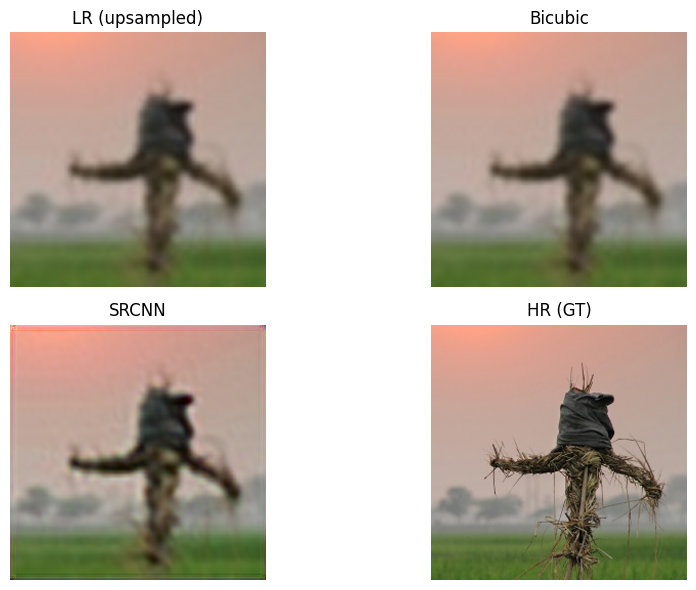

Saved to: /content/srcnn_compare


In [41]:
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path("/content/srcnn_compare")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def t2pil(x):
    return TF.to_pil_image(x.squeeze(0).cpu().clamp(0,1))

def save_compare(id_="0100"):
    lr_path = find_img(LR_DIR, id_)
    hr_path = find_img(HR_DIR, id_)

    lr = TF.to_tensor(Image.open(lr_path).convert("RGB")).unsqueeze(0).to(device)
    hr = TF.to_tensor(Image.open(hr_path).convert("RGB")).unsqueeze(0).to(device)

    with torch.no_grad():
        bic = bicubic_up(lr, 4)
        sr  = model(bic).clamp(0,1)

    lr_view = bic  # show LR as upscaled

    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(2,2,1); ax.imshow(t2pil(lr_view)); ax.set_title("LR (upsampled)"); ax.axis("off")
    ax = fig.add_subplot(2,2,2); ax.imshow(t2pil(bic));     ax.set_title("Bicubic"); ax.axis("off")
    ax = fig.add_subplot(2,2,3); ax.imshow(t2pil(sr));      ax.set_title("SRCNN"); ax.axis("off")
    ax = fig.add_subplot(2,2,4); ax.imshow(t2pil(hr));      ax.set_title("HR (GT)"); ax.axis("off")
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"{id_}_COMPARE.png", dpi=150)
    plt.show()
    plt.close(fig)

save_compare("0101")
print("Saved to:", OUT_DIR)

Test

In [40]:
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF
from pathlib import Path

def find_img(folder: Path, id_: str):
    for ext in [".png", ".jpg", ".jpeg"]:
        p = folder / f"{id_}{ext}"
        if p.exists():
            return p
    raise FileNotFoundError(f"Missing file for id={id_} in {folder}")

def bicubic_up(x, scale=4):
    return F.interpolate(x, scale_factor=scale, mode="bicubic", align_corners=False).clamp(0,1)

def psnr(sr, hr):
    mse = F.mse_loss(sr, hr)
    return 10 * torch.log10(1.0 / mse)

bic_psnrs = []
with torch.no_grad():
    for id_ in test_ids:
        lr = TF.to_tensor(Image.open(find_img(LR_DIR, id_)).convert("RGB")).unsqueeze(0).to(device)
        hr = TF.to_tensor(Image.open(find_img(HR_DIR, id_)).convert("RGB")).unsqueeze(0).to(device)
        bic = bicubic_up(lr, 4)
        bic_psnrs.append(psnr(bic, hr).item())

print("Bicubic Test PSNR:", float(np.mean(bic_psnrs)))

Bicubic Test PSNR: 23.051351928710936


In [19]:
from PIL import Image

for id_ in ["0100","0101","0102","0103"]:
    lr_path = find_img(LR_DIR, id_)
    hr_path = find_img(HR_DIR, id_)
    lr = Image.open(lr_path)
    hr = Image.open(hr_path)
    print(id_, "LR:", lr.size, "HR:", hr.size, "|", lr_path.name, hr_path.name)

0100 LR: (64, 64) HR: (256, 256) | 0100.jpg 0100.jpg
0101 LR: (64, 64) HR: (256, 256) | 0101.jpg 0101.jpg
0102 LR: (64, 64) HR: (256, 256) | 0102.jpg 0102.jpg
0103 LR: (64, 64) HR: (256, 256) | 0103.jpg 0103.jpg


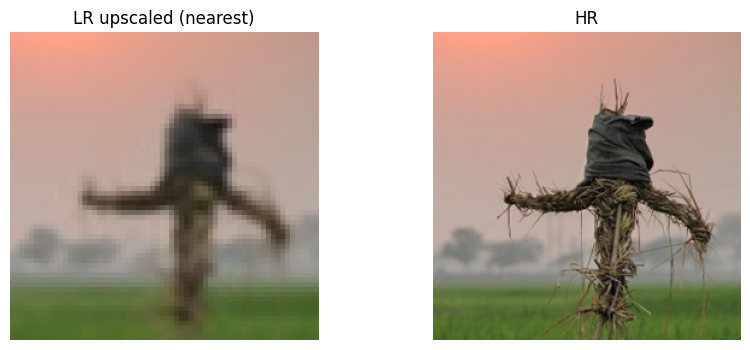

In [22]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

id_ = "0101"
lr = TF.to_tensor(Image.open(find_img(LR_DIR, id_)).convert("RGB")).unsqueeze(0).to(device)
hr = TF.to_tensor(Image.open(find_img(HR_DIR, id_)).convert("RGB")).unsqueeze(0).to(device)

lr_up = F.interpolate(lr, scale_factor=4, mode="nearest")
hr_cpu = hr.squeeze(0).cpu()
lr_up_cpu = lr_up.squeeze(0).cpu()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(TF.to_pil_image(lr_up_cpu)); plt.title("LR upscaled (nearest)"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(TF.to_pil_image(hr_cpu)); plt.title("HR"); plt.axis("off")
plt.show()

# **Save File**

In [42]:
import shutil

shutil.copy(
    "/content/best_srcnn_x4.pth",
    "/content/drive/MyDrive/content/sr_project/best_srcnn_x4.pth"
)

print("✅ Model saved to Drive")

✅ Model saved to Drive


In [43]:
import shutil

shutil.make_archive("/content/srcnn_compare", "zip", "/content/srcnn_compare")

shutil.copy(
    "/content/srcnn_compare.zip",
    "/content/drive/MyDrive/content/sr_project/srcnn_compare.zip"
)

print("✅ Comparison results saved")

✅ Comparison results saved
